============================================
Groundwater Forecast WITHOUT wells influence
+ Residual Anomaly Detection
+ Lag Quantification
============================================

0. Imports

In [1]:
%pip install tensorflow shap

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.ensemble import IsolationForest
from scipy.stats import ttest_ind

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

print("TensorFlow:", tf.__version__)

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
c:\Users\peliz\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\peliz\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


TensorFlow: 2.19.0


1. Load Data

In [2]:
BASE_PATH = "."

level = pd.read_csv(os.path.join(BASE_PATH, "data/nivel-pocos_chuva_pressao_tratados.csv"))
wells = pd.read_csv(os.path.join(BASE_PATH, "data/funcionamento_pocos_30min.csv"))
tide  = pd.read_csv(os.path.join(BASE_PATH, "data/earth_tide.csv"))

rename_map = {
    "pressao_mH2O_final": "baro_ig_mH2O",
    "gmu_level_mH2O_compensado": "gmu_gwl_mH2O",
    "chuva_mm_30min": "rain_mm_30min",
    "status_IMECC": "status_IME",
    "status_ZOOLOGIA": "status_IBZ",
}

level = level.rename(columns=rename_map)
wells = wells.rename(columns=rename_map)

# padronizar datetime
def fix_datetime(df):
    for col in ["date_time", "datetime", "time", "Date"]:
        if col in df.columns:
            df = df.rename(columns={col: "date_time"})
            df["date_time"] = pd.to_datetime(df["date_time"])
            return df
    raise ValueError("No datetime column found")

level = fix_datetime(level)
wells = fix_datetime(wells)
tide  = fix_datetime(tide)

# merge
data = (
    level
    .merge(wells, on="date_time", how="outer")
    .merge(tide, on="date_time", how="outer")
)

data = data.sort_values("date_time").reset_index(drop=True)

2. Filter Period

In [3]:
START = "2024-12-08 23:00:00"
END   = "2025-08-14 16:00:00"

data = data[(data["date_time"] >= START) & (data["date_time"] <= END)]
df = data.set_index("date_time")

3. Feature Engineering (WITHOUT wells)

In [4]:
target = "gmu_gwl_mH2O"

df["gwl_lag_6h"] = df[target].shift(12)
df["gwl_diff_24h"] = df[target] - df[target].shift(48)
df["trend_component"] = df[target].rolling(336, min_periods=1).mean()
df["rain_sum_7d"] = df["rain_mm_30min"].rolling(336, min_periods=1).sum()
df["weekday"] = (df.index.weekday < 5).astype(int)

engineered = [
    "gwl_lag_6h",
    "gwl_diff_24h",
    "trend_component",
    "rain_sum_7d",
    "weekday"
]

wells_cols = ["status_IME", "status_FEF", "status_IBZ"]

natural = [
    col for col in df.columns
    if col not in ([target] + engineered + wells_cols)
]

features = natural + engineered

df_model = df[[target] + features].copy()
mask = df_model.notna().all(axis=1).values

4. Split (70% train / 30% test)

In [5]:
X = df_model[features].values
y = df_model[[target]].values

n = len(df_model)
train_end = int(n * 0.7)

X_train_raw = X[:train_end]
y_train_raw = y[:train_end]
m_train     = mask[:train_end]

X_test_raw  = X[train_end:]
y_test_raw  = y[train_end:]
m_test      = mask[train_end:]

5. Scaling

In [6]:
sx = MinMaxScaler()
sy = MinMaxScaler()

sx.fit(X_train_raw[m_train])
sy.fit(y_train_raw[m_train])

X_train = sx.transform(X_train_raw)
X_test  = sx.transform(X_test_raw)

y_train = sy.transform(y_train_raw)
y_test  = sy.transform(y_test_raw)

6. Sequence

In [7]:
def seq(X,y,mask,win):
    Xs, ys = [], []
    for i in range(win, len(X)):
        if not mask[i-win:i+1].all():
            continue
        Xs.append(X[i-win:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

win = 240

X_train, y_train = seq(X_train, y_train, m_train, win)
X_test,  y_test  = seq(X_test,  y_test,  m_test,  win)

7. LSTM

In [8]:
def build(input_shape):
    model = Sequential([
        LSTM(128, return_sequences=True, input_shape=input_shape),
        Dropout(0.05),
        LSTM(64, return_sequences=True),
        Dropout(0.05),
        LSTM(32),
        Dense(1)
    ])
    
    model.compile(loss="mse", optimizer=Adam(5e-4))
    return model

model = build((X_train.shape[1], X_train.shape[2]))

es = EarlyStopping(patience=10, restore_best_weights=True)

model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    callbacks=[es],
    verbose=1
)

c:\Users\peliz\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 81s 309ms/step - loss: 0.0137
Epoch 2/50


c:\Users\peliz\anaconda3\Lib\site-packages\keras\src\callbacks\early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss
  current = self.get_monitor_value(logs)


253/253 ━━━━━━━━━━━━━━━━━━━━ 81s 319ms/step - loss: 3.7307e-04
Epoch 3/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 85s 337ms/step - loss: 3.2707e-04
Epoch 4/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 79s 310ms/step - loss: 2.5739e-04
Epoch 5/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 71s 279ms/step - loss: 2.3650e-04
Epoch 6/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 60s 238ms/step - loss: 2.4517e-04
Epoch 7/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 76s 299ms/step - loss: 1.9842e-04
Epoch 8/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 86s 339ms/step - loss: 1.9792e-04
Epoch 9/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 79s 311ms/step - loss: 2.1129e-04
Epoch 10/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 82s 322ms/step - loss: 1.3724e-04
Epoch 11/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 91s 358ms/step - loss: 1.4629e-04
Epoch 12/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 86s 339ms/step - loss: 1.3368e-04
Epoch 13/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 85s 337ms/step - loss: 1.3558e-04
Epoch 14/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 86s 338ms/step - loss: 1.0610e-04
Epoch 15/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 88s

8. Evaluation

In [9]:
y_pred_s = model.predict(X_test)

y_pred = sy.inverse_transform(y_pred_s)
y_true = sy.inverse_transform(y_test)

print("R2:", r2_score(y_true, y_pred))
print("MAE:", mean_absolute_error(y_true, y_pred))

105/105 ━━━━━━━━━━━━━━━━━━━━ 14s 132ms/step
R2: 0.9991092956126923
MAE: 0.025840478179059177


9. Residuals

In [10]:
residuals = y_true.flatten() - y_pred.flatten()

timestamps = df_model.index[
    win + train_end :
    win + train_end + len(y_test)
]

df_res = pd.DataFrame({"residual": residuals}, index=timestamps)

10. Anomaly Detection

In [11]:
iso = IsolationForest(contamination=0.02, random_state=42)

df_res["anomaly"] = iso.fit_predict(df_res[["residual"]])
df_res["is_anomaly"] = (df_res["anomaly"] == -1).astype(int)

11. Plot

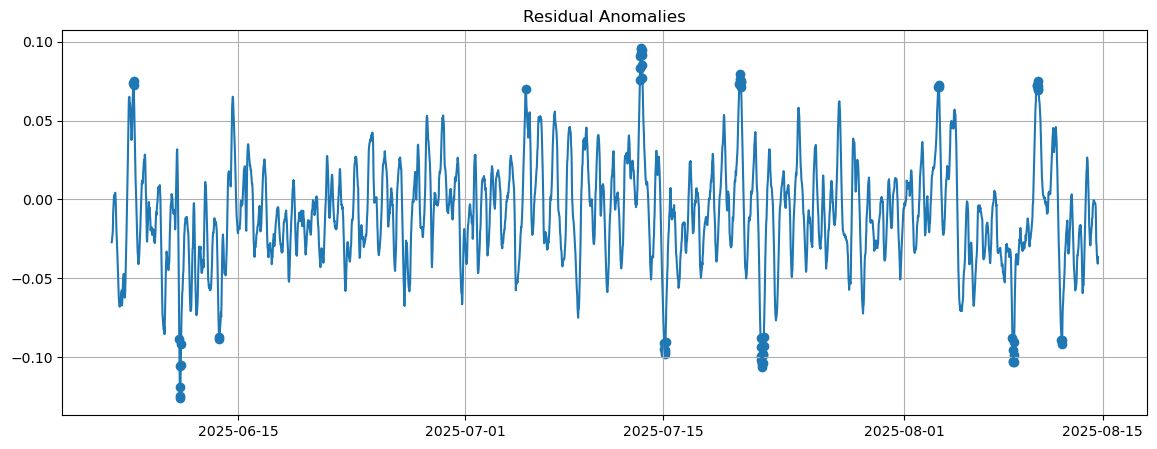

In [12]:
plt.figure(figsize=(14,5))
plt.plot(df_res.index, df_res["residual"])
plt.scatter(
    df_res.index[df_res["is_anomaly"]==1],
    df_res["residual"][df_res["is_anomaly"]==1],
)
plt.title("Residual Anomalies")
plt.grid()
plt.show()

12. Merge with wells

In [13]:
df_status = df.loc[df_res.index, wells_cols]
df_all = pd.concat([df_res, df_status], axis=1).dropna()

13. Correlation

In [14]:
for col in wells_cols:
    print(col, df_all["is_anomaly"].corr(df_all[col]))

status_IME 0.006998583674152849
status_FEF -0.018150932680911253
status_IBZ -0.0412810427307831


14. Anomaly Rate

In [15]:
for col in wells_cols:
    on = df_all[df_all[col]==1]["is_anomaly"].mean()
    off = df_all[df_all[col]==0]["is_anomaly"].mean()
    print(col, "ON:", on, "OFF:", off)

status_IME ON: 0.020948180815876516 OFF: 0.018979057591623036
status_FEF ON: 0.016408386508659983 OFF: 0.02182628062360802
status_IBZ ON: 0.014459224985540775 OFF: 0.026038437693738377


15. Statistical Test

In [16]:
for col in wells_cols:
    g1 = df_all[df_all[col]==1]["residual"]
    g0 = df_all[df_all[col]==0]["residual"]
    _, p = ttest_ind(g1,g0,equal_var=False)
    print(col, "p=", p)

status_IME p= 5.995770523506784e-85
status_FEF p= 0.0003109857113752037
status_IBZ p= 0.04092972988332678


16. Event Analysis

In [17]:
window = 24

for col in wells_cols:
    events = df_all.index[df_all[col].diff()==1]
    vals = []

    for t in events:
        i = df_all.index.get_loc(t)
        if i-window<0 or i+window>=len(df_all):
            continue
        seg = df_all.iloc[i-window:i+window]
        vals.append(seg["is_anomaly"].sum())

    print(col, "mean anomalies:", np.mean(vals))

status_IME mean anomalies: 0.75
status_FEF mean anomalies: 0.8048780487804879
status_IBZ mean anomalies: 0.9736842105263158


17. Lag via correlation


status_IME → best lag: 0 steps (0 min)


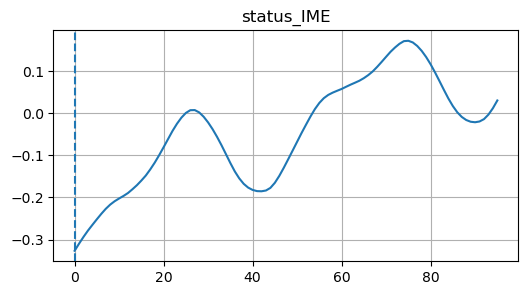


status_FEF → best lag: 43 steps (1290 min)


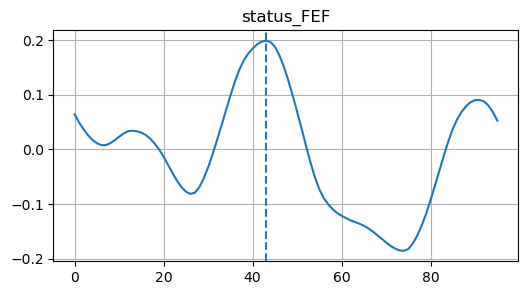


status_IBZ → best lag: 74 steps (2220 min)


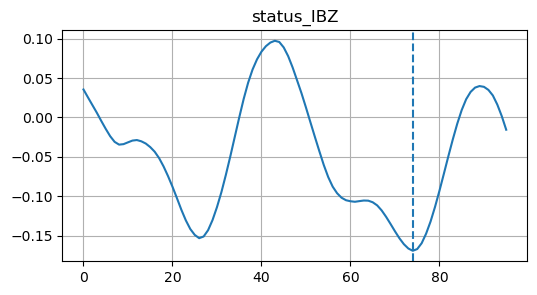

In [18]:
def compute_lag(residual, status, max_lag=96):
    lags = np.arange(max_lag)
    corrs = []

    for lag in lags:
        if lag == 0:
            r = np.corrcoef(residual, status)[0,1]
        else:
            r = np.corrcoef(residual[lag:], status[:-lag])[0,1]
        corrs.append(r)

    return lags, np.array(corrs)

for col in wells_cols:

    res = df_all["residual"].values
    stat = df_all[col].values

    mask_valid = ~np.isnan(res) & ~np.isnan(stat)

    lags, corrs = compute_lag(res[mask_valid], stat[mask_valid])

    best_lag = lags[np.argmax(np.abs(corrs))]

    print(f"\n{col} → best lag: {best_lag} steps ({best_lag*30} min)")

    plt.figure(figsize=(6,3))
    plt.plot(lags, corrs)
    plt.axvline(best_lag, linestyle="--")
    plt.title(col)
    plt.grid()
    plt.show()

18. Lag via anomaly response


status_IME → anomaly lag: 23 steps (690 min)


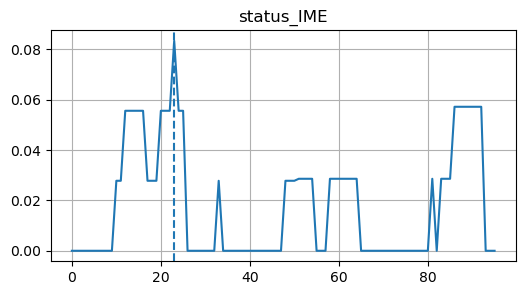


status_FEF → anomaly lag: 49 steps (1470 min)


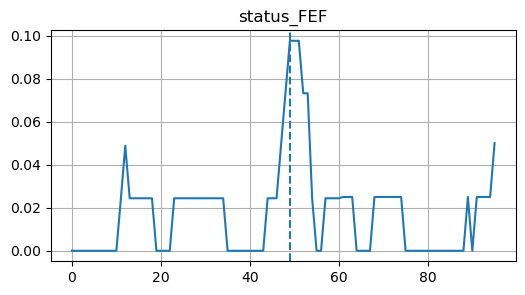


status_IBZ → anomaly lag: 91 steps (2730 min)


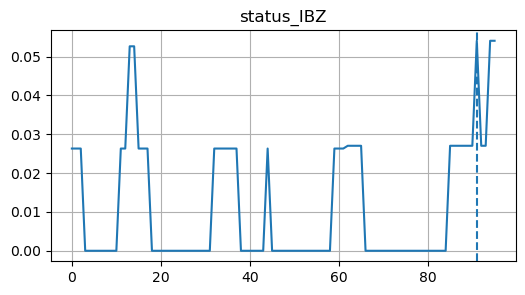

In [19]:
def lag_anomaly_response(df, status_col, max_lag=96):

    events = df.index[df[status_col].diff() == 1]
    scores = np.zeros(max_lag)

    for lag in range(max_lag):

        vals = []

        for t in events:
            i = df.index.get_loc(t)

            if i + lag >= len(df):
                continue

            vals.append(df.iloc[i + lag]["is_anomaly"])

        if len(vals) > 0:
            scores[lag] = np.mean(vals)

    return scores

for col in wells_cols:

    scores = lag_anomaly_response(df_all, col)

    best_lag = np.argmax(scores)

    print(f"\n{col} → anomaly lag: {best_lag} steps ({best_lag*30} min)")

    plt.figure(figsize=(6,3))
    plt.plot(scores)
    plt.axvline(best_lag, linestyle="--")
    plt.title(col)
    plt.grid()
    plt.show()

# 7.1 Save model and preprocessing artifacts

In [1]:
# %%
import joblib
import json

SAVE_PATH = "model_artifacts"
os.makedirs(SAVE_PATH, exist_ok=True)

# salvar modelo (Keras)
model.save(os.path.join(SAVE_PATH, "lstm_model.keras"))

# salvar scalers
joblib.dump(sx, os.path.join(SAVE_PATH, "scaler_X.pkl"))
joblib.dump(sy, os.path.join(SAVE_PATH, "scaler_y.pkl"))

# salvar metadados importantes
metadata = {
    "features": features,
    "target": target,
    "window_size": win
}

with open(os.path.join(SAVE_PATH, "metadata.json"), "w") as f:
    json.dump(metadata, f)

print("✅ Modelo salvo com sucesso em:", SAVE_PATH)

NameError: name 'os' is not defined